# Treinamento com interface de alto nível

## Importação das bibliotecas

In [1]:
# http://pytorch.org/
from os.path import exists

import torch

In [15]:
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR
import pandas as pd
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
use_cuda = torch.cuda.is_available()
torch.manual_seed(1111)
device = torch.device("cuda" if use_cuda else "cpu")

##Preparação dos Dados




In [4]:
#!/bin/bash
!curl -L -o /content/blood-donor-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/sumedh1507/blood-donor-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  484k  100  484k    0     0   419k      0  0:00:01  0:00:01 --:--:--  419k


In [5]:
!unzip /content/blood-donor-dataset.zip

Archive:  /content/blood-donor-dataset.zip
  inflating: blood_donor_dataset.csv  


In [6]:
df = pd.read_csv("/content/blood_donor_dataset.csv")

In [7]:
df.head()

,donor_id,name,email,password,contact_number,city,blood_group,availability,months_since_first_donation,number_of_donation,pints_donated,created_at
0,1b8b4c828a,Norma Fisher,ysullivan@yahoo.com,P5hX6Syg*A,+61 461706749,Hobart,A+,No,65,31,62,2017-03-17
1,a6a3f7fe55,Eugene Bowman,hramos@brown-sellers.com,b6Wq6Cqz@5,+61 450709944,Darwin,AB-,Yes,64,8,16,2016-11-11
2,cee6478144,Sheri Bolton DDS,jasmine85@hotmail.com,$9RB51m#s7,+61 428756361,Melbourne,AB+,Yes,39,6,6,2022-02-25
3,5986bc55f9,Kelly Boyd,pattylawrence@riley-hayes.com,@5Tdg(4kCm,+61 454318320,Darwin,A-,No,55,20,20,2025-04-04
4,93246afe6c,Taylor Guzman,martinezjacob@wilson.com,x!)9Ag@J*7,+61 484158472,Darwin,O-,No,7,35,35,2022-11-30


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   donor_id                     10000 non-null  object
 1   name                         10000 non-null  object
 2   email                        10000 non-null  object
 3   password                     10000 non-null  object
 4   contact_number               10000 non-null  object
 5   city                         10000 non-null  object
 6   blood_group                  10000 non-null  object
 7   availability                 10000 non-null  object
 8   months_since_first_donation  10000 non-null  int64 
 9   number_of_donation           10000 non-null  int64 
 10  pints_donated                10000 non-null  int64 
 11  created_at                   10000 non-null  object
dtypes: int64(3), object(9)
memory usage: 937.6+ KB


In [11]:
for col in df.columns:
  if df[col].dtype == 'object':
    df[col] = LabelEncoder().fit_transform(df[col])

In [13]:
df.head()

,donor_id,name,email,password,contact_number,city,blood_group,availability,months_since_first_donation,number_of_donation,pints_donated,created_at
0,1095,7075,9828,6073,5812,4,0,0,65,31,62,591
1,6562,3070,3555,7859,4555,3,3,1,64,8,16,471
2,8127,8234,3894,855,2086,5,2,1,39,6,6,2272
3,3504,5121,6905,4595,4974,3,1,0,55,20,20,3326
4,5768,8644,5665,9747,8277,3,7,0,7,35,35,2534


In [17]:
correlation = df.corr()['availability'].sort_values(ascending=False)
correlation

,availability
availability,1.000000
password,0.014759
email,0.009595
number_of_donation,0.009434
name,0.006133
created_at,0.006057
pints_donated,0.005817
months_since_first_donation,0.004873
city,0.004795
donor_id,-0.001671


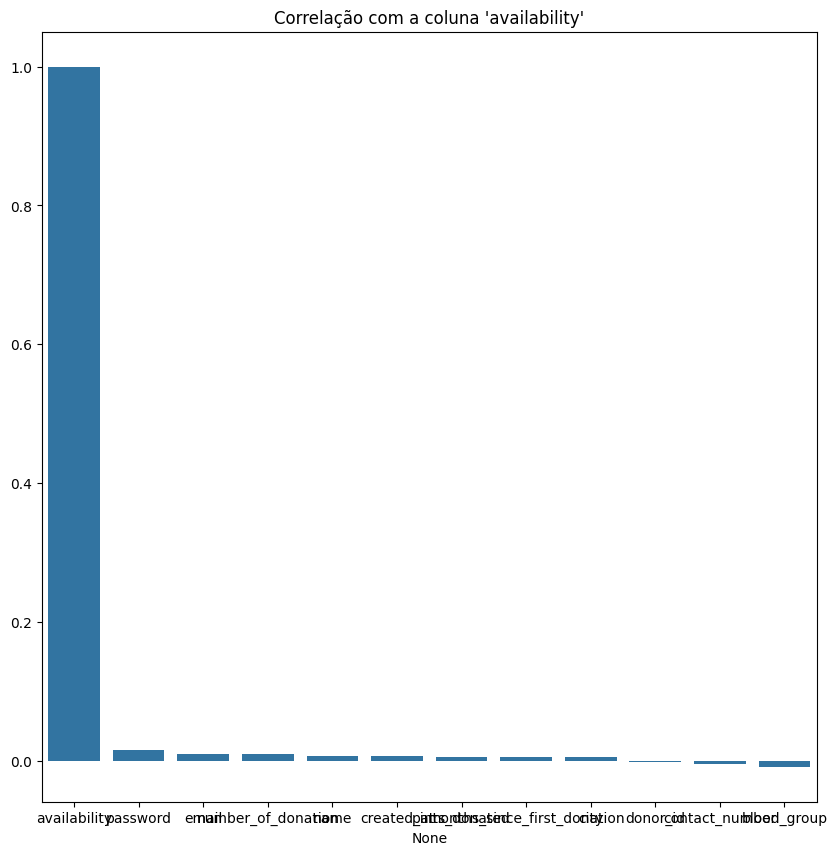

In [19]:
plt.figure(figsize=(10, 10))
sns.barplot(x=correlation.index, y=correlation.values)
plt.title("Correlação com a coluna 'availability'")
plt.show()

In [21]:
correlation

,availability
availability,1.000000
password,0.014759
email,0.009595
number_of_donation,0.009434
name,0.006133
created_at,0.006057
pints_donated,0.005817
months_since_first_donation,0.004873
city,0.004795
donor_id,-0.001671


In [22]:
features = ['number_of_donation','created_at','pints_donated','months_since_first_donation','city']
target = 'availability'

X = df[features].values
Y = df[target].values

In [27]:
X.shape

(10000, 5)

In [28]:
class BloodDonationDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [29]:

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

X_scaler = StandardScaler()
X_train = X_scaler.fit_transform(X_train)
X_test = X_scaler.transform(X_test)

In [30]:
train_dataset = BloodDonationDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
test_dataset = BloodDonationDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test))

In [31]:
train_kwargs = {'batch_size': 100}
test_kwargs = {'batch_size': 100}
if use_cuda:
    cuda_kwargs = {'num_workers': 1,
                    'pin_memory': True,
                    'shuffle': True}
    train_kwargs.update(cuda_kwargs)
    test_kwargs.update(cuda_kwargs)

train_loader = torch.utils.data.DataLoader(train_dataset,**train_kwargs)
test_loader = torch.utils.data.DataLoader(test_dataset, **test_kwargs)

## Criação da rede

In [34]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.input = nn.Linear(X_train.shape[1], 128)
        self.drop1 = nn.Dropout(0.3)
        self.hidden = nn.Linear(128, 256)
        self.drop2 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 2)

    def forward(self, x):
        x = self.input(x)
        x = F.relu(x)
        x = self.drop1(x)
        x = self.hidden(x)
        x = F.relu(x)
        x = self.drop2(x)
        x = self.fc2(x)
        return x

model = Net()

In [35]:
model

Net(
  (input): Linear(in_features=5, out_features=128, bias=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (hidden): Linear(in_features=128, out_features=256, bias=True)
  (drop2): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=2, bias=True)
)

## Treinamento

### Criando o objeto de treinamento

In [36]:
def train(model, device, train_loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * data.size(0)
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100 * correct / len(train_loader.dataset)
    return train_loss, train_acc


In [37]:
def test(model, device, test_loader, criterion):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item() * data.size(0)
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    test_acc = 100. * correct / len(test_loader.dataset)

    return test_loss, test_acc

## Avaliação

In [38]:
epochs = 100
lr = 0.001
lr_decay = 10
patience = 10
patience_counter = 0
best_acc = 0

history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

model = Net().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()
scheduler = StepLR(optimizer, step_size=lr_decay, gamma=0.5)

print("Iniciando Treinamento ...")

for epoch in range(1, epochs + 1):

  train_loss, train_acc = train(model, device, train_loader, optimizer, criterion)
  test_loss, test_acc = test(model, device, test_loader, criterion)
  scheduler.step()

  print(f"Época: {epoch} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

  history['train_loss'].append(train_loss)
  history['train_acc'].append(train_acc)
  history['test_loss'].append(test_loss)
  history['test_acc'].append(test_acc)

  if test_acc > best_acc:
    best_acc = test_acc
    print("Salvando melhor época ...")
    torch.save(model.state_dict(), "mnist_cnn.pt")
    patience_counter = 0
  else:
    patience_counter += 1
    if patience_counter == patience:
      print(f"Parando Treinamento por Patience na época {epoch}...")
      break

Iniciando Treinamento ...
Época: 1 | Train Loss: 0.6978, Train Acc: 50.79% | Test Loss: 0.6964, Test Acc: 48.50%
Salvando melhor época ...
Época: 2 | Train Loss: 0.6966, Train Acc: 50.87% | Test Loss: 0.6955, Test Acc: 49.27%
Salvando melhor época ...
Época: 3 | Train Loss: 0.6943, Train Acc: 50.23% | Test Loss: 0.6963, Test Acc: 49.60%
Salvando melhor época ...
Época: 4 | Train Loss: 0.6935, Train Acc: 51.14% | Test Loss: 0.6966, Test Acc: 50.37%
Salvando melhor época ...
Época: 5 | Train Loss: 0.6934, Train Acc: 51.09% | Test Loss: 0.6960, Test Acc: 49.53%
Época: 6 | Train Loss: 0.6929, Train Acc: 51.09% | Test Loss: 0.6970, Test Acc: 50.80%
Salvando melhor época ...
Época: 7 | Train Loss: 0.6933, Train Acc: 50.89% | Test Loss: 0.6958, Test Acc: 50.27%
Época: 8 | Train Loss: 0.6920, Train Acc: 52.19% | Test Loss: 0.6955, Test Acc: 49.70%
Época: 9 | Train Loss: 0.6922, Train Acc: 51.70% | Test Loss: 0.6958, Test Acc: 49.67%
Época: 10 | Train Loss: 0.6930, Train Acc: 51.24% | Test Loss

## Visualização dos Resultados

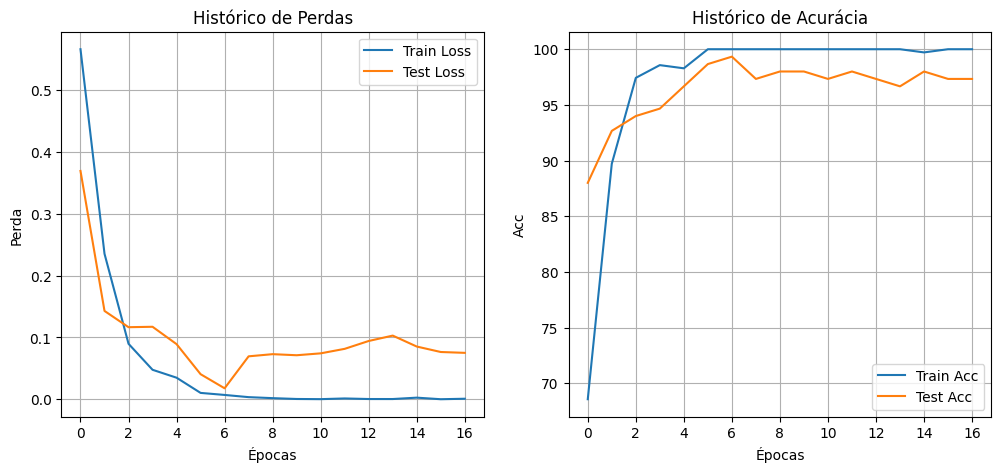

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 5))

#Perda
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['test_loss'], label='Test Loss')
plt.title('Histórico de Perdas')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.grid(True)

#Acurácia
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['test_acc'], label='Test Acc')
plt.title('Histórico de Acurácia')
plt.xlabel('Épocas')
plt.ylabel('Acc')
plt.legend()
plt.grid(True)

plt.show()